# 01. Population Modelling and Forecasting

## 1. Setup

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

sys.path.append('src')
from stationarity_diagnostics import plot_acf_diagnostics, stationarity_test

## 2. Data loading and reshaping

Currently the data has columns as years and rows as the population types. We use the `melt` function to convert this wide data into long format to make it cleaner for analysis.

In [2]:
df = pd.read_csv('data/IndicatorsOnPopulationAnnual.csv')

long_df = df.melt(id_vars=["DataSeries"], var_name="Year", value_name="Value")
long_df["Year"] = long_df["Year"].astype(int)                        
long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")  # non-numeric entries -> NaN
long_df.head()

,DataSeries,Year,Value
0,Total Population,2025,6111175.0
1,Resident Population,2025,4204515.0
2,Singapore Citizen Population,2025,3660683.0
3,Permanent Resident Population,2025,543832.0
4,Non-Resident Population,2025,1906660.0


## 3. Exploratory analysis

Isolating each population series from `long_df`, then plotting the trendlines for total population then for the whole.

In [3]:
def get_series(name):
    s = long_df[long_df["DataSeries"] == name].copy() #.copy() method prevents pandas from confusing new dataset with the old after iterations.
    s.sort_values('Year', inplace=True)
    return s

total_df       = get_series("Total Population")
resident_df    = get_series("Resident Population")
SC_df          = get_series("Singapore Citizen Population")
PR_df          = get_series("Permanent Resident Population")
nonresident_df = get_series("Non-Resident Population")

total_df.head()

,DataSeries,Year,Value
2175,Total Population,1950,1022100.0
2146,Total Population,1951,1068100.0
2117,Total Population,1952,1127000.0
2088,Total Population,1953,1191800.0
2059,Total Population,1954,1248200.0


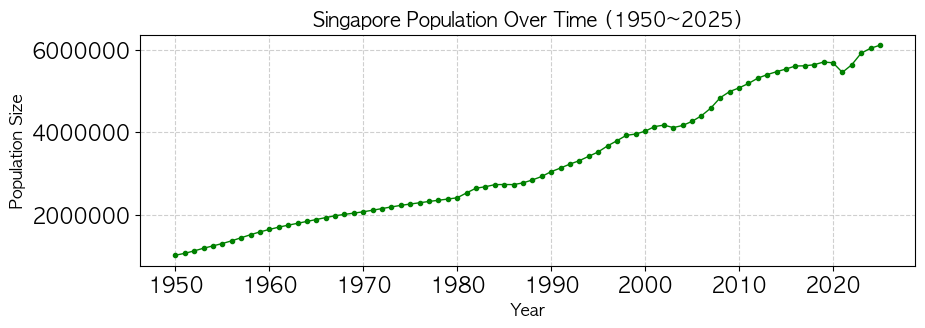

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(total_df["Year"], total_df["Value"], marker="o", markersize=3, linewidth=1, color="green")

plt.title("Singapore Population Over Time (1950~2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population Size", fontsize=12)
plt.ticklabel_format(style="plain", axis="y")  # no scientific notation on y-axis
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

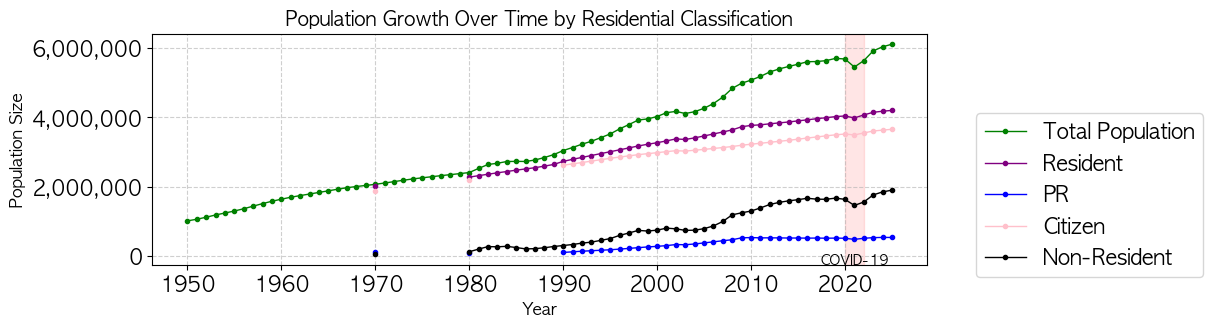

In [5]:
plt.figure(figsize=(10, 3))
plt.plot(total_df["Year"], total_df["Value"], marker="o", markersize=3, linewidth=1, color="green", label="Total Population")
plt.plot(resident_df["Year"], resident_df["Value"], marker="o", markersize=3, linewidth=1, color="purple", label="Resident")
plt.plot(PR_df["Year"], PR_df["Value"], marker="o", markersize=3, linewidth=1, color="blue", label="PR")
plt.plot(SC_df["Year"], SC_df["Value"], marker="o", markersize=3, linewidth=1, color="pink", label="Citizen")
plt.plot(nonresident_df["Year"], nonresident_df["Value"], marker="o", markersize=3, linewidth=1, color="black", label="Non-Resident")

plt.title("Population Growth Over Time by Residential Classification", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population Size", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 0.7), loc="upper left")

plt.axvspan(2020, 2022, color="red", alpha=0.1)
plt.text(x=2021, y=plt.ylim()[0] + 16, s="COVID-19", color="black",
         fontsize=10, weight="bold", ha="center")

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
plt.show()

Surprisingly, the growth trend for Residents and Singapore Citizens appears to be highly linear. For a country like Singapore that experienced exponential economic growth, I expected population to also grow exponentially, which does not seem to be the case.

Resident Population is made up of Citizens and PR who have a usual place of residence in Singapore AND stay in Singapore for longer than 12 months ([SingStat definition](https://www.singstat.gov.sg/find-data/explore-data-themes/population/population-and-population-structure/our-data-explained)). Exogenous shocks such as COVID-19, while decreasing resident population slightly, do not seem to have affected the overall growth much. I noticed at a later stage of this project while testing ADF on this series that there is a gap in data for residents between 1970 and 1980. For proper time series analysis, we shoud be taking the starting datapoint as 1980 instead.

Over 1980 to 2025, external forces such as immigration policy and geopolitical shifts and natural growth net out to an approximately linear path for Resident growth. This can be statistically tested. 

## 4. Scope: Why I am using Resident Population for COE prediction

Since the main purpose of the COE is to restrict the volume of cars on the road, we will make a judgement here that resident growth is the key concern for the government in implementing COE quotas. While wealthier non-residents or overseas SCs and PRs may choose to keep a car in Singapore, they will rarely use it on the road. In the lens of microeconomics, the utility functions of non-residents and residents are different. While the price of cars (which COE holds a significant weight on) is the same for both groups, the utility of owning a car is significantly higher for residents since they can use it on day-to-day basis while non-residents use it seasonally or only as an investment vehicle. 

Therefore, most of the demand for cars and therefore coe permits will come from residents. While official government publications use total population for their models, using resident only should help in reducing noise and churn out better demand estimation. This project direction is slightly supported through personal observation of my friends on student pass and their overreliance on GRAB rather than public transport, but not necessarily considering car purchases.

We will be mainly considering resident population to approximate demand. While other factors may affect road congestion such as road condition and availability and advancements in public transport, the number of cars on the road should be the main driver.

## 5. Data cleaning

Chronologically, the aforementioned data gap was discovered while testing ADF in Section 6. For coherency of this notebook, I only left the revised data cleaning portion here. Initially, when testing ADF on the whole resident data series, we received a negative test statistic of -14.3. This allowed us to lookback on the original dataset to notice the 1970-1980 gap that puts a 10 year growth in one year difference, which caused an outlier contamination of test regression. As shown in Section 6, plotting from 1980 gives us a more plausible statistic.

In [6]:
resident_df.dropna(inplace=True)
resident_df = resident_df[resident_df['Year'] >= 1980].reset_index(drop=True)
resident_df.head()

,DataSeries,Year,Value
0,Resident Population,1980,2282125.0
1,Resident Population,1981,2324403.0
2,Resident Population,1982,2365707.0
3,Resident Population,1983,2406165.0
4,Resident Population,1984,2443705.0


## 6. Stationarity diagnostics

We will first create ACF and PACF plots for level and first & second differenced population value. The inspection of the plots can help us understand the data and modeling direction as well as choosing the number of lags or differencing for the models. We are using log population as differences of logs are approximately annual growth rates and the log stabilises the variance of a growing series.

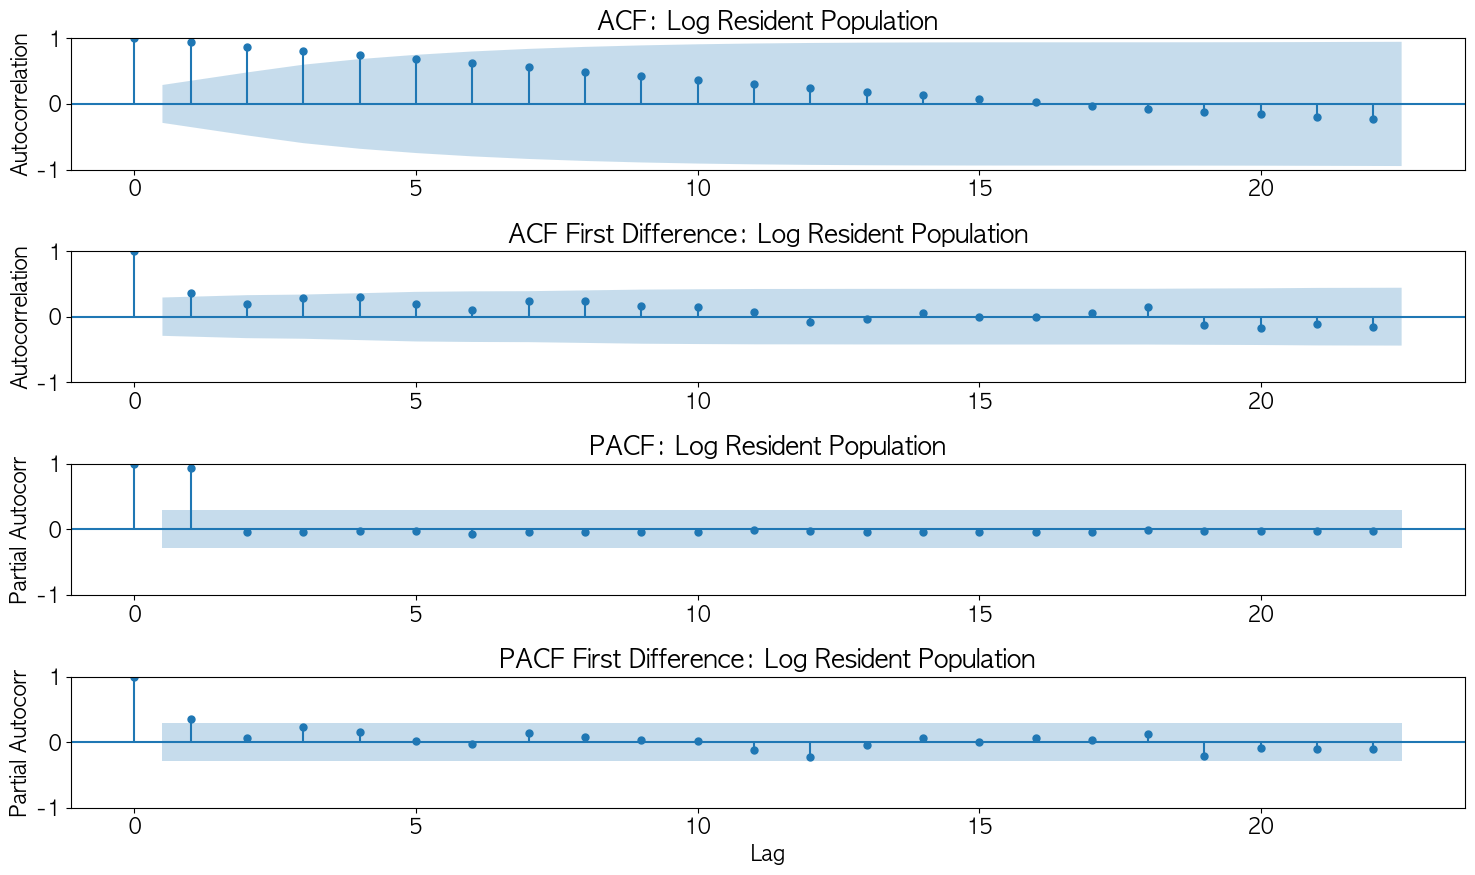

In [7]:
y = np.log(resident_df['Value'].values)

plot_acf_diagnostics(y, 'Log Resident Population', lags=22); #function imported from separate file. 22 is maximum lag value from n = 45

For the log-level ACF plot, the lags decay slowly, which is expected from a trending series — this indicates non-stationarity in the levels and motivates differencing. At the first difference, there is a single spike above the significance band at lag 1 the cuts off quickly, showing statistically significant lag-1 autocorrelation: successive growth rates are serially correlated. Because all later lags are inside the band, the first difference looks stationary, so d = 1 appears sufficient for the ARIMA model, with the lag-1 structure captured by AR/MA terms rather than further differencing.

For the level PACF plot, there is a single spike at lag 1 with a value near 1 — this is consistent with d = 1 direction, rather than a stationary AR(1). For the first difference, there is a smaller spike at lag 1 with the rest inside the band, suggesting the growth rates contain AR(1) structure.

There does not seem to be a noticeably seasonality in the data as expected from a year series of population.

We also difference the series a second time to check for overdifferencing.

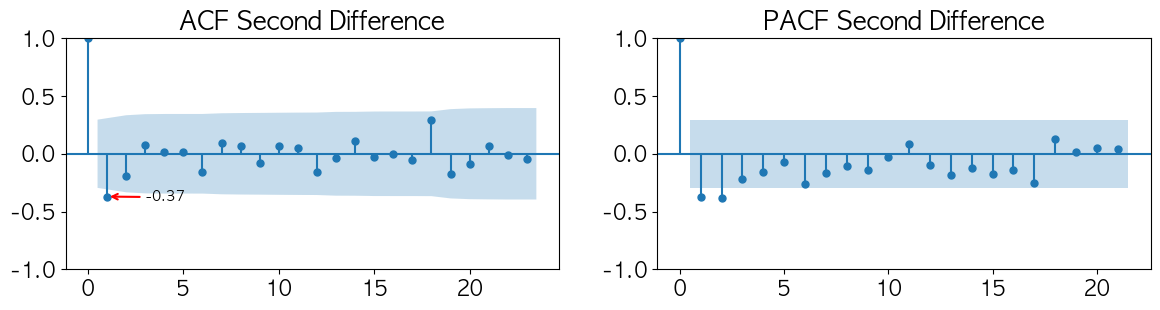

In [8]:
fig2, ax2 = plt.subplots(1, 2, figsize = (14, 3))
val2 = np.diff(np.diff(y))
acf_vals = acf(val2, nlags = 23)
lag1_val = acf_vals[1]

plot_acf(val2, lags=23, ax = ax2[0], title = "ACF Second Difference");
ax2[0].annotate(f'{lag1_val:.2f}',
            xy=(1, lag1_val),
            xytext=(3, lag1_val-0.04),
            fontsize=10,
            ha='left',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red', lw=1.5))


plot_pacf(val2, lags=21, ax = ax2[1], title = "PACF Second Difference");

The second-difference ACF shows a negative spike at lag 1 of about −0.37. If the first difference were white noise, overdifferencing it would produce the approximate value of −0.5. At −0.37 the evidence is inconclusive: it sits between the overdifferencing signature (−0.5) and what second-differencing a stationary AR(1) growth series would produce (≈ −0.3), so we cannot tell from this plot alone whether d = 2 is necessary. If it is not overdifferenced, this would indicate a MA(1) trend.

The second-difference PACF shows two spikes beyond the band, then appears to decay in the bracket. This complements MA(1) finding instead of indicating an AR(2) term. This is indicative of ARIMA(0,2,1) if d = 2 is the correct differencing.

Since the visual diagnostics cannot settle d, we complement them with formal ADF and KPSS tests — noting that with n = 46 these tests also have limited power, and hence I will handle final model selection using AICc and Out of Sample Comparison.

Below, I have plotted the actual differenced series for visual comparison with the ACF plots

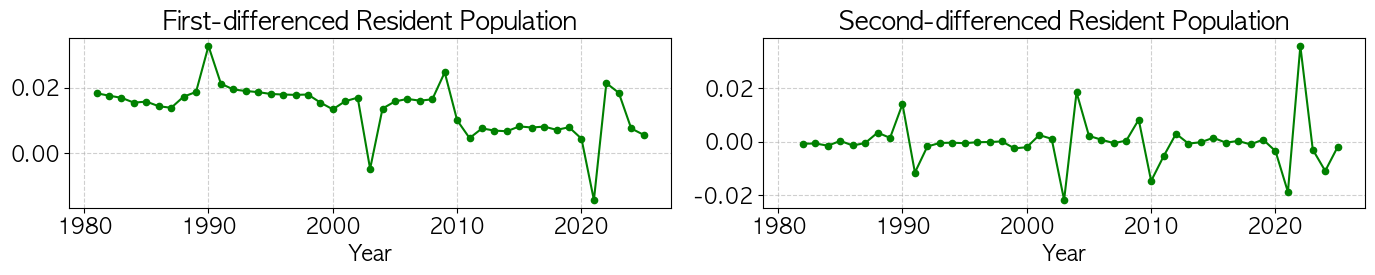

In [9]:
fig_diff, ax_diff = plt.subplots(1, 2, figsize=(14, 3), sharex=True)
ax_diff[0].plot(resident_df['Year'][1:], np.diff(y), marker="o", markersize=4.5, linewidth=1.5, color="green")
ax_diff[0].set_title("First-differenced Resident Population")
ax_diff[0].set_xlabel("Year")
ax_diff[1].plot(resident_df['Year'][2:], val2, marker="o", markersize=4.5, linewidth=1.5, color="green")
ax_diff[1].set_title("Second-differenced Resident Population")
for axis_d in ax_diff:
    axis_d.grid(True, linestyle="--", alpha=0.6)
    axis_d.ticklabel_format(style="plain", axis="y")
ax_diff[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

By visual inspection the initial population numbers rise in a roughly straight line, which motivates testing them with regression='ct'. However, the first difference appears not as a horizontal trend but drifts downward, which is what a decelerating — non-linear — trend would look like, and the second difference sits around zero. For the differenced series we test with regression='c', since a linear trend in levels becomes a constant mean in the differences. If the first difference is judged non-stationary while the second is stationary by both ADF and KPSS, the series is I(2): its slope itself changes, which is evidence against a fixed linear trend.

In [10]:
warnings.filterwarnings('ignore', message = r"The test") #Removes interpolation warning message for cleaness
stationarity_test(y, 'log levels', 'ct')
stationarity_test(np.diff(y), 'first difference', 'c')
stationarity_test(val2, 'second difference', 'c')

--- log levels (n=46) ---
  ADF:  stat= -0.0611  p=0.9936  FAIL TO REJECT (unit root)
  KPSS: stat=  0.2538  p=0.0100  REJECT H0 (non-stationary)
  => ✗ NON-STATIONARY (both tests agree)

--- first difference (n=45) ---
  ADF:  stat= -4.3579  p=0.0004  REJECT H0 (stationary)
  KPSS: stat=  0.7899  p=0.0100  REJECT H0 (non-stationary)
  => ? AMBIGUOUS (tests conflict or weak evidence)

--- second difference (n=44) ---
  ADF:  stat= -5.9839  p=0.0000  REJECT H0 (stationary)
  KPSS: stat=  0.2326  p=0.1000  FAIL TO REJECT (stationary)
  => ✓ STATIONARY (both tests agree)



Tests conclude that log levels is not a deterministic linear trend and second difference is stationary. While, first difference is inconclusive, the first two test results give us enough information about our data. Since our sample size is small, while expecting I(2) models to win, we will also plot d = 1 ARIMA models for Out of Sample test to properly select our models.

> Note: An interpolation warning arises as the standard lookup table for KPSS test does not contain p-value lower than 0.01, so the result received is 0.01 despite actual value being lower. Since whether or not p > 0.05 determines failing to reject or not to reject the null hypothesis, this warning is irrelevant for this test.

## 7. Splitting Train-Test Samples

The data is split at 2018 where we are fitting on 1980–2018 (n = 38) and testing on 2019–2025 (n = 7). This allows us to train models with as much data as possible while still leaving a seven-year holdout to see forecasting capabilities for long horizon. I also considered splitting at 2019, but that makes 2020, a COVID-shock year, the very first point the model is scored on, so the holdout error would be dominated by an anomaly right at the start. The 2018 split instead puts a normal year (2019) first and lets the COVID dip (2021–2022) fall inside the test window, along with the rebound we assume by 2024–2025 that is visible on the chart — giving a more representative test.

Since the model is only trained up to 2018, the 2019 to 2025 values are completely new, which makes this a fair test of the model rather than something overfitted model can predict. We would not expect it to catch the 2021 to 2022 dip, because a univariate model only carries forward its own history and cannot see a shock like Covid coming. But it can still land close to the 2025 value, since the dip was temporary and the series came back to the path the model projected. Missing the dip while still hitting the endpoint is really what a temporary shock looks like. And because 2025 is the furthest point out, if the model manages to bracket it within its prediction interval, it tells us the trend the model learned before 2018 still holds. Even so, this is only one point inside a wide interval, so passing it is a criterion for the model to pass but it is not the proof that the model is right.

In [11]:
years_r = resident_df['Year']
pop_r = resident_df['Value']
train_split = years_r <= 2018
test_split = years_r > 2018 

train_years, train_pop = years_r[train_split], pop_r[train_split]
test_years, test_pop = years_r[test_split], pop_r[test_split]
train_diff = np.diff(train_pop)
train_diff

array([ 42278.,  41304.,  40458.,  37540.,  38910.,  35983.,  35266.,
        44594.,  49169.,  88241.,  58836.,  55050.,  54793.,  54803.,
        54165.,  54617.,  55271.,  56615.,  49663.,  43682.,  52539.,
        57042., -16053.,  46375.,  54548.,  58080.,  57188.,  59577.,
        91217.,  37845.,  17530.,  28954.,  26546.,  25988.,  31951.,
        30869.,  32237.,  28487.])

## 8. ARIMA candidate race

Given the uncertainty of whether the model should be d = 1 or d = 2 from Section 6, some ARIMA candidates is fitted on the log scale and judged on three measures. 

1. AICc to measure goodness of fit but it is only comparable between models that share the same d.
2. Ljung Box test checks whether a model leaves any autocorrelation behind in its residuals, which tells us whether the fit is adequate rather than ranking one model above another.
3. Holdout MASE test measures how well each model forecasts data it has not seen, and unlike AICc it stays comparable across every model in the grid.

This stage is to get an idea of how models actually perform against the tests. For the final selection, we will be using both level and log, and including ETS models as well.

In [12]:
warnings.filterwarnings('ignore', message = r"Maximum Likelihood") #Removes error message then dealt later.
train = np.log(train_pop)
test = np.log(test_pop)

LB_LAGS = 8   # lags checked for leftover autocorrelation (Hyndman default for non seasonal data). Chose 8 due to small sample size 39.
                                                                                                # -> min(10, n/5) around 8

# We set drift as the benchmark since ADF/KPSS tests were inconclusive. 
#                                            Drift: d=1 with trend='t'. Good performance indicates constant linear trend in log scale.
candidates = {
    'drift(0,1,0)+c':  dict(order=(0, 1, 0), trend='t'),
    'ARIMA(0,1,1)':    dict(order=(0, 1, 1)),
    'ARIMA(0,1,2)':    dict(order=(0, 1, 2)),
    'ARIMA(1,1,0)':    dict(order=(1, 1, 0)),
    'ARIMA(1,1,1)':    dict(order=(1, 1, 1)),
    'ARIMA(0,2,1)':    dict(order=(0, 2, 1)), #In Section 6, we picked ARIMA(0,2,1) as the prime candidate. However, we have added or 
                                                #removed one more AR or MA term to solidify our findings as series is small.
    'ARIMA(0,2,2)':    dict(order=(0, 2, 2)),
    'ARIMA(1,2,0)':    dict(order=(1, 2, 0)),
    'ARIMA(1,2,1)':    dict(order=(1, 2, 1)),
}

def mase(test, y_pred, train):
    scale = np.mean(np.abs(np.diff(train)))       # in-sample naive MAE
    return np.mean(np.abs(test - y_pred)) / scale

rows, fits = [], {}
for name, spec in candidates.items():
    fit = ARIMA(train, **spec).fit(method_kwargs={'maxiter': 1000})
    fits[name] = fit
    pred_log = fit.forecast(len(test))
    m = mase(np.exp(test), np.exp(pred_log), np.exp(train))  # scored on the original scale to check how far the model misses the actual mean.

    # Ljung Box on residuals. H0 = residuals are white noise (no leftover autocorrelation).
    # df is reduced by the p+q estimated ARMA terms, otherwise the test runs too lenient.
    p, d, q = spec['order']
    resid = np.asarray(fit.resid)[fit.loglikelihood_burn:]
    lb_p = acorr_ljungbox(resid, lags=[LB_LAGS], model_df=p + q,
                          return_df=True)['lb_pvalue'].iloc[0]

    rows.append((name, fit.aicc, m, lb_p, "White Noise" if lb_p > 0.05 else "Autocorrelated"))

log_results = (pd.DataFrame(rows, columns=['model', 'AICc', 'holdout_MASE', 'LB_pvalue', 'Residuals'])
               .sort_values('holdout_MASE').reset_index(drop=True))
log_results

,model,AICc,holdout_MASE,LB_pvalue,Residuals
0,"ARIMA(1,2,0)",-269.648619,0.505460,0.076078,White Noise
1,"ARIMA(0,2,1)",-273.723920,0.579825,0.249841,White Noise
2,"ARIMA(0,2,2)",-272.134708,0.610023,0.295624,White Noise
3,"ARIMA(1,1,1)",-276.583669,0.627753,0.323475,White Noise
4,"ARIMA(1,2,1)",-272.131933,0.627775,0.269048,White Noise
5,"ARIMA(1,1,0)",-271.642739,0.851376,0.206676,White Noise
6,"ARIMA(0,1,2)",-243.304888,1.808143,0.048674,Autocorrelated
7,"ARIMA(0,1,1)",-232.081238,2.092607,0.014938,Autocorrelated
8,"drift(0,1,0)+c",-272.927522,3.124900,0.005426,Autocorrelated


While Drift has one of the lowest AICc value, it fails terribly on holdout MASE at 3.12 where benchmark is at 1. It also has the lowest p-value among all the models, meaning there is still information left in the residuals. For ARIMA (0,1,1) and (0,1,2), they have much higher AICc value as well as failing on both tests. So these three models will be discarded.

Looking at the other results, we can see each tests have different leading models, showing that there are no clear winners here. Ljung-Box test will be used to discard models that rejects the null hypothesis i.e. there are information left in its residuals without ranking the p-value.

>**holdout_MASE**: ARIMA(1,2,0)

>**AICc**: ARIMA(1,1,1) for d = 1, ARIMA(0,2,1) for d = 2

Also, looking at ARIMA(1,1,1) and ARIMA(1,2,1) we notice that the model's performance on holdout_MASE is almost identical: same value up until the fourth decimal place. Since the two models are suggesting one unit root vs two unit rootm respectively, it invites an investigation of whether ARIMA(1,1,1) model is pushing its AR term close to 1 where it would behave like another unit root on top of d = 1, almost making it the same as differencing twice.

While the standard practice is to take the logs to stabilise variance, we will be using original levels to test these models as well to see the actual difference. And we will also be plotting ETS models for final model selection process.

>However, we received an error. *"ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals"*. Despite increasing maxiter value by 10 times, the error persists, showing that a definite solution could not be reached. We will conduct a check to see which models are failing the covergence, since non-converged value cannot be relied on as its residuals are unreliable.

In [13]:
for name, fit in fits.items():
    print(name, getattr(fit, 'mle_retvals', {}).get('converged', 'n/a'))

drift(0,1,0)+c True
ARIMA(0,1,1) True
ARIMA(0,1,2) True
ARIMA(1,1,0) True
ARIMA(1,1,1) True
ARIMA(0,2,1) False
ARIMA(0,2,2) False
ARIMA(1,2,0) False
ARIMA(1,2,1) True


We can see that the models which failed to converge are all d = 2 models except ARIMA(1,2,1). This might mean that a log series differenced twice seem to strain the optimiser but not always. Since ARIMA(1,2,0) and ARIMA(0,2,1), our leading models, were among those that failed to converge, we cannot simply pick them, as their estimates are unreliable. We will investigate this effect in Section 10 and attempt to use other optimisers.

## 9. Test - Omitted Drift for ARIMA(p,1,q) models and presence of unit root

Properly testing the statistical models, because two independent analyses disagreed on method: does the AR(1) coefficient of the differenced series stay near 1 once a drift term is included?

### Testing findings

In [14]:
print(fits['ARIMA(1,1,1)'].params['ar.L1'],
      fits['ARIMA(1,1,0)'].params['ar.L1'],
      fits['ARIMA(1,2,1)'].params['ar.L1'])

0.9690388759480247 0.9072346393294791 0.13900654582892902


The two once differenced models come back with AR coefficients very close to one, 0.97 for ARIMA(1,1,1) and 0.91 for ARIMA(1,1,0), while the twice differenced ARIMA(1,2,1) sits at a reasonable 0.14. An AR root near one in a model that has already been differenced once is a warning sign, and it has two readings we need to separate. This implies the the model contains a unit root and therefore stationary. ([Unit Root Explanation](https://www.iiqf.org/blogs/quantitative-finance/unit-root-processes-time-series-analysis.html))

The first reading is that the series really wants a second difference. A once differenced model can imitate a twice differenced one by pushing its AR root toward one, because one difference followed by an AR root near one is almost the same as differencing twice. If that is what is happening, these models are quietly pointing at d = 2.

The second reading is that we left the drift out. The differenced series has a clear positive average, which is just the steady upward slope of the population. If we fit the AR without a constant to absorb that average, the coefficient inflates toward one to stand in for the missing mean. Here the near unit root would be the result of our own specification, not a feature of the data, and d = 1 should work fine once the drift is put back.

The two readings predict opposite things when we add the drift back, so we can tell them apart. If the series genuinely needs a second difference the coefficient stays near one. If it was only covering for the missing drift, it collapses to the plain lag one autocorrelation of the differences.

In [15]:
# Putting the omitted drift back and see whether the near-unit AR root survives.
dy = np.diff(train)   # first difference of the log training series

def ar_l1(order, trend=None):
    f = ARIMA(train, order=order, **({'trend': trend} if trend else {})).fit()
    return np.array(f.params)[f.param_names.index('ar.L1')]

print("raw lag-1 autocorr of differences :", round(pd.Series(dy).autocorr(1), 4))
print("ARIMA(1,1,0) ar.L1  no trend      :", round(ar_l1((1, 1, 0)), 4))
print("ARIMA(1,1,0) ar.L1  with trend='t':", round(ar_l1((1, 1, 0), 't'), 4))
print("ARIMA(1,1,1) ar.L1  no trend      :", round(ar_l1((1, 1, 1)), 4))
print("ARIMA(1,1,1) ar.L1  with trend='t':", round(ar_l1((1, 1, 1), 't'), 4))

raw lag-1 autocorr of differences : 0.4868
ARIMA(1,1,0) ar.L1  no trend      : 0.9072
ARIMA(1,1,0) ar.L1  with trend='t': 0.4933
ARIMA(1,1,1) ar.L1  no trend      : 0.969
ARIMA(1,1,1) ar.L1  with trend='t': 0.7598


Adding the drift collapses the coefficient, which is the second reading. On the training sample the ARIMA(1,1,0) root falls from 0.91 to 0.49, and 0.49 is essentially the raw lag one autocorrelation of the differences, so the coefficient has simply dropped to the value it should have had all along. ARIMA(1,1,1) tells the same story more weakly, dropping from 0.97 to 0.76 rather than all the way, because its MA term may have soaked up some of the same structure, which is itself a sign that ARMA(1,1) is reliant on only 39 points. So the near unit root was caused by omitted drift, not a hidden second difference, and d = 1 with drift goes back in as a serious candidate rather than something the earlier fits had quietly ruled out. Again, we source out our final decision to AICc and Out of Sample test and give I(1) model a fair chance.

## 10. Final model selection: ARIMA (drift-corrected) + ETS, both scales

In [16]:
naive_scale = np.mean(np.abs(train_diff))    # in-sample naive MAE, straight from the split
h           = len(test_pop)
test_level  = test_pop.values

def mase_final(pred):
    return float(np.mean(np.abs(test_level - pred)) / naive_scale)

arima_specs = {
    "drift(0,1,0)+c": dict(order=(0, 1, 0), trend='t'),
    "ARIMA(1,1,0)":   dict(order=(1, 1, 0), trend='t'),
    "ARIMA(1,1,1)":   dict(order=(1, 1, 1), trend='t'),
    "ARIMA(0,1,1)":   dict(order=(0, 1, 1), trend='t'),
    "ARIMA(1,1,2)":   dict(order=(1, 1, 2), trend='t'),   # not the same reduced form as damped Holt due to added trend term
    "ARIMA(0,2,1)":   dict(order=(0, 2, 1)),
    "ARIMA(1,2,0)":   dict(order=(1, 2, 0)),
    "ARIMA(1,2,1)":   dict(order=(1, 2, 1)),
    "ARIMA(0,2,2)":   dict(order=(0, 2, 2)),   # same reduced form as Holt's linear trend
    "ARIMA(0,2,0)":   dict(order=(0, 2, 0)),   # simplest d=2 model, no ARMA terms
}

rows2 = []
final_fits = {}
for scale, train_series, back in [("log", np.log(train_pop.values), np.exp),
                                  ("level", train_pop.values, lambda x: x)]:
    for name, spec in arima_specs.items():
        fit = ARIMA(train_series, **spec).fit(method_kwargs={'method': 'nm', 'maxiter': 2000})
        final_fits[(scale, name)] = fit
        p, d, q = spec['order']
        resid = np.asarray(fit.resid)[fit.loglikelihood_burn:]
        lb_p = acorr_ljungbox(resid, lags=[LB_LAGS], model_df=p + q, return_df=True)['lb_pvalue'].iloc[0]
        rows2.append((scale, name, mase_final(back(np.asarray(fit.forecast(h)))), fit.aicc, lb_p,
                      "White Noise" if lb_p > 0.05 else "Autocorrelated"))

    for damped in (False, True):
        fit = ETSModel(pd.Series(train_series), error='add', trend='add', damped_trend=damped).fit(disp=False)
        final_fits[(scale, "ETS damped" if damped else "ETS Holt")] = fit
        lb = acorr_ljungbox(fit.resid, lags=[8], model_df=3 if damped else 2, return_df=True)['lb_pvalue'].iloc[0]
        rows2.append((scale, "ETS damped" if damped else "ETS Holt",
                      mase_final(back(np.asarray(fit.forecast(h)))), fit.aicc, lb, "White Noise" if lb > 0.05 else "Autocorrelated"))

race_table = (pd.DataFrame(rows2, columns=['scale', 'model', 'holdout_MASE', 'AICc', 'LB_P-value', 'Residuals'])
              .sort_values('holdout_MASE').reset_index(drop=True))
print(race_table.to_string(index=False))

scale          model  holdout_MASE        AICc  LB_P-value      Residuals
  log   ARIMA(1,2,0)      0.505188 -269.652546    0.079234    White Noise
  log   ARIMA(0,2,0)      0.522376 -266.720100    0.109249    White Noise
level   ARIMA(0,2,2)      0.551796  848.580947    0.022461 Autocorrelated
level   ARIMA(0,2,1)      0.552026  846.224569    0.038647 Autocorrelated
level   ARIMA(1,2,0)      0.552026  846.224585    0.038644 Autocorrelated
level   ARIMA(0,2,0)      0.552115  843.992404    0.061772    White Noise
  log   ARIMA(0,2,1)      0.573038 -273.725386    0.249602    White Noise
level       ETS Holt      0.597384  886.157255    0.108341    White Noise
level     ETS damped      0.602291  888.904480    0.062045    White Noise
  log       ETS Holt      0.615125 -283.957234    0.138678    White Noise
  log   ARIMA(0,2,2)      0.792315 -272.405039    0.380748    White Noise
level   ARIMA(1,2,1)      0.826006  847.552264    0.021550 Autocorrelated
  log   ARIMA(1,2,1)      0.881795 -27

Reading the race, three things stand out, and the residual column now backs them up.

1. The differencing order is settled by the out of sample column, not by the tests. Every d = 1 model, the drift benchmark and ARIMA(1,1,1) included, sits at a MASE between 1.7 and 3.1, far worse than the naive benchmark of 1, while every d = 2 model sits near 0.5. So the holdout value gives a clear answer that the series behaves like d = 2 over this window. This rejects our prediction that the population extrapolates as a linear line.

2. The model performance is highly reliant on scale. On the log scale the d = 2 models spread out and rank cleanly, ARIMA(1,2,0) at 0.505, ARIMA(0,2,0) at 0.522, ARIMA(0,2,1) at 0.573, and all three leave white noise residuals. On the level scale the same models pile up around 0.552 within a thousandth of each other, and most of them now fail the residual test as well. This shows that the model can barely adjust its parameters due to much larger values compared to logs and fails to learn from the data. Hence, leaving all the patterns stuck in the residuals. We read the ranking off the log scale and treat the level rows as unreliable.

3. The simplest model nearly wins. ARIMA(0,2,0), which has no AR or MA term at all, comes second overall, passes the residual test, and beats the richer ARIMA(0,2,1) and ARIMA(0,2,2). Adding parameters does not improve the holdout, and on AICc only ARIMA(0,2,1) is preferred within the log d = 2 block, by a margin the forecasts do not reward. This is the parsimony signal, the extra terms are fitting noise, which is what we expect once the residuals are already close to white noise.

On the level scale Holt's linear trend and the damped trend score almost the same, 0.597 against 0.602 on MASE, so damping barely changes anything and the data does not seem to call for it. On the log scale the damped model does much worse, 1.128 against 0.615 for Holt, but this appears to be an unstable fit rather than a real difference, so we set that number aside.

More interesting is that our reference book treats Holt's linear trend and the damped trend as mathematically equivalent in reduced form to ARIMA(0,2,2) and ARIMA(1,1,2), yet here they score differently on MASE. This shows a genuine difference in how the two families are estimated; they count their parameters and handle their starting conditions differently as well as estimate likelihood differently, so models that are identical on paper are not fit the same way in practice. We expected the received values to be close as the reference book emphasised its mathematical equivalence but it shows that it does not translate to equivalent results.

That gap between theory and practice appeared throughout the project, sometimes as this kind of genuine difference between methods, and sometimes as plain numerical trouble, such as the fits that would not converge until the solver was changed. Working through the models rather than only reading about them is what brought both to the surface. So this project allowed us to see how the textbook models actually perform.

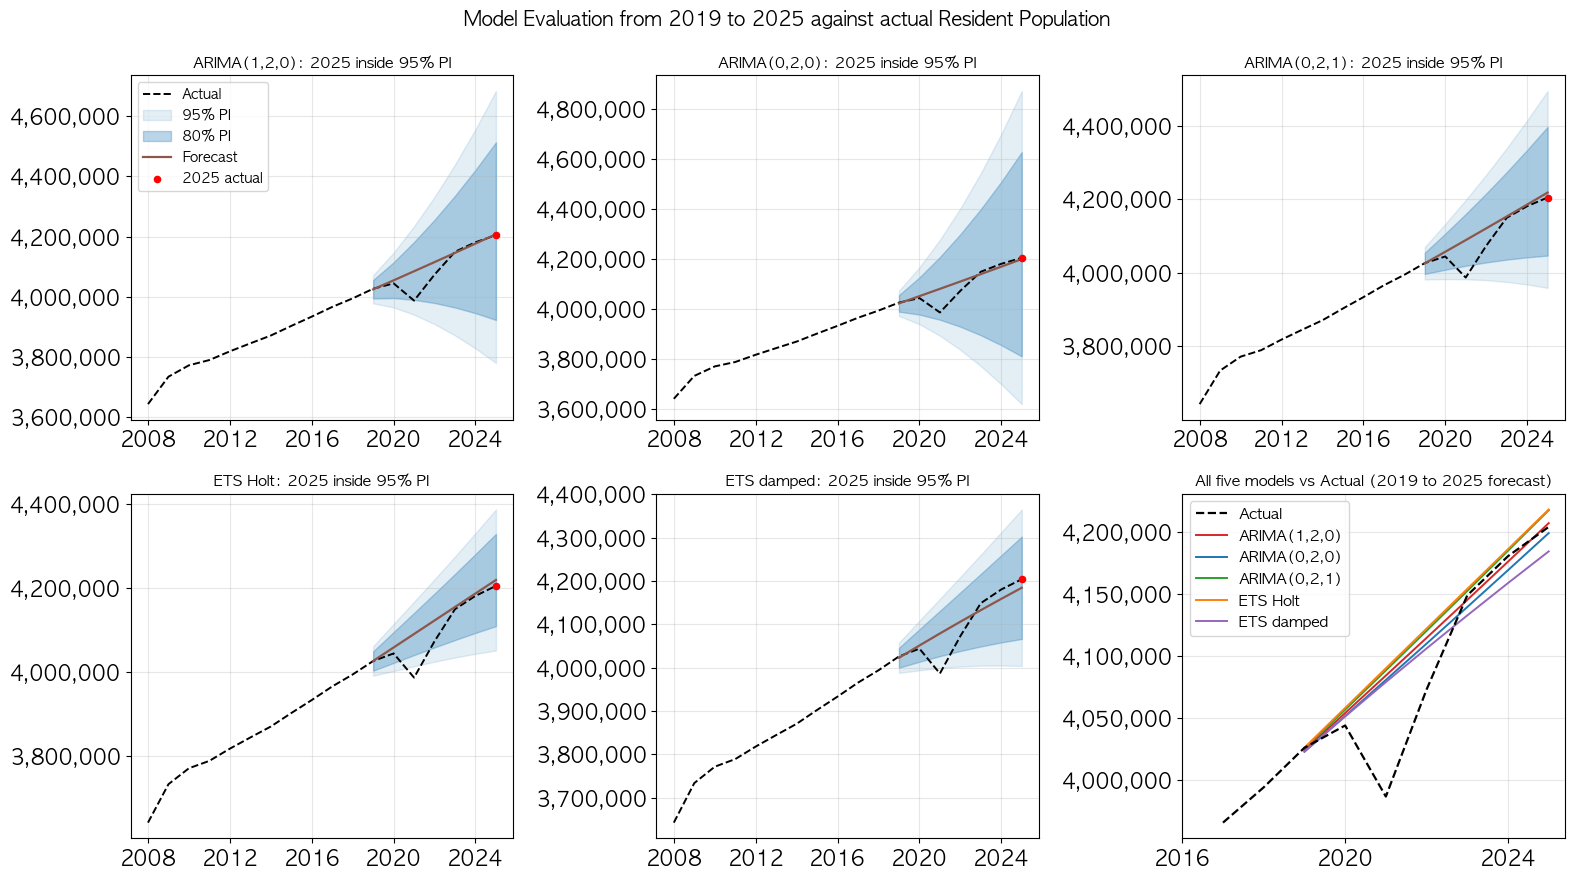

In [17]:
n_tr        = len(train_pop)
tyears      = test_years.values #2019-2025
actual_test = test_pop.values

chosen = [("ARIMA(1,2,0)", "log"), ("ARIMA(0,2,0)", "log"), ("ARIMA(0,2,1)", "log"),
          ("ETS Holt", "level"), ("ETS damped", "level")]

def intervals(name, scale):
    fit  = final_fits[(scale, name)]
    back = np.exp if scale == "log" else (lambda x: x)
    if "ETS" in name:
        pr = fit.get_prediction(start=n_tr, end=n_tr + h - 1)
        f95, f80 = pr.summary_frame(alpha=0.05), pr.summary_frame(alpha=0.20)
        vals = (f95['mean'].values, f80['pi_lower'].values, f80['pi_upper'].values,
                f95['pi_lower'].values, f95['pi_upper'].values)
    else:
        pr = fit.get_forecast(h)
        c95, c80 = np.asarray(pr.conf_int(alpha=0.05)), np.asarray(pr.conf_int(alpha=0.20))
        vals = (np.asarray(pr.predicted_mean), c80[:, 0], c80[:, 1], c95[:, 0], c95[:, 1])
    return [np.asarray(back(v)) for v in vals]

fig_eval, axes_eval = plt.subplots(2, 3, figsize=(16, 9))
axes_eval = axes_eval.ravel()
show = years_r.values >= 2008

for ax_ev, (name, scale) in zip(axes_eval, chosen):
    fc_mean, lo80, hi80, lo95, hi95 = intervals(name, scale)
    ax_ev.plot(years_r.values[show], pop_r.values[show], color='black', ls='--', lw=1.4, label='Actual')
    ax_ev.fill_between(tyears, lo95, hi95, color='tab:blue', alpha=0.12, label='95% PI')
    ax_ev.fill_between(tyears, lo80, hi80, color='tab:blue', alpha=0.30, label='80% PI')
    ax_ev.plot(tyears, fc_mean, color='tab:brown', ls='-', lw=1.6, label='Forecast')
    inside = lo95[-1] <= actual_test[-1] <= hi95[-1]
    ax_ev.scatter([tyears[-1]], [actual_test[-1]], s=20, zorder=5,
               color=('red' if inside else 'crimson'), label='2025 actual')
    ax_ev.set_title(f"{name}: 2025 {'inside' if inside else 'OUTSIDE'} 95% PI", fontsize=11)
    ax_ev.grid(True, alpha=0.3)
    ax_ev.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax_ev.set_xticks(range(2008, 2026, 4))

axes_eval[0].legend(loc='upper left', fontsize=10)

palette = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple']
axes_eval[5].plot(years_r.values[years_r > 2016], pop_r.values[years_r > 2016], color="black", linestyle="--", linewidth=1.6, label="Actual", zorder=5)
for (name, scale), colr in zip(chosen, palette):
    fc_mean = intervals(name, scale)[0]                                  # forecast mean, from the race fits
    axes_eval[5].plot(tyears, fc_mean, linewidth=1.4, color=colr, label=name)
axes_eval[5].set_title("All five models vs Actual (2019 to 2025 forecast)", fontsize=11)
axes_eval[5].grid(True, alpha=0.3)
axes_eval[5].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes_eval[5].set_xticks(range(2016, 2026, 4))
# axes_eval[5]._shared_y_axes.remove(axes_eval[5])
# axes_eval[5].yaxis.set_major_locator(plt.MaxNLocator())
# axes_eval[5].autoscale(axis='y')
axes_eval[5].legend(loc="upper left", fontsize=11)

fig_eval.suptitle('Model Evaluation from 2019 to 2025 against actual Resident Population', fontsize=14)
plt.tight_layout()
plt.show()

We can see here that the actual 2025 values comfortably land within 80% interval close to forecasts. So we can see that the initial hypothesis holds where the model may miss the COVID shock but predicts the 2025 rebound well. Again, this is not a part of the formal tests but rather just testing my hypothesis.
>Models do not share the same y axis scale to allow for better observation of each models and 2025 datapoint. In reality, the prediction intervals for ETS models are much narrower, making 2025 point less visible.

### Final Model Selection

Overall, ARIMA(1,2,0) is the best forecaster by a small margin, carrying a single mild AR term of about -0.37. ARIMA(0,2,0) is essentially tied, has nothing to estimate, and leaves cleaner residuals, so it is the most honest baseline. ETS Holt is a respectable non ARIMA alternative at about 0.60 but does not beat them. AICc value, while it is the highest, is not comparable to ARIMA models as the underlying.

We carry three ARIMA models, ARIMA(1,2,0), ARIMA(0,2,0) and ARIMA(0,2,1) (Due to high AICc despite low MASE). We will also bring Holt and damped trend as an ARIMA alternative as we cannot compare its AICc; model fits may have been better, despite slightly worse MASE performance. However, the gap between the top models in terms of MASE is small on a single seven point holdout that contains COVID and with limited sample size. So this is a limitation of the project, hence why we are bringing 5 models to the following section on COE forecasting.

## 11. Forecast: five best models on the full sample

The five best models are refit on the full 1980–2025 resident series, then its in-sample fit is plotted against the actual data, and it forecasts `H` years ahead with 80% and 95% prediction intervals — the 80% band drawn bolder than the 95% band.

In [18]:
H = 10
pop_level    = pop_r.values.astype(float)                                   # full series, from Section 7
pop_log      = np.log(pop_level)
future_years = np.arange(years_r.values[-1] + 1, years_r.values[-1] + 1 + H)   # 2026 ... 2035

best5 = [
    ("ARIMA(1,2,0)", "log",   dict(order=(1, 2, 0))),
    ("ARIMA(0,2,0)", "log",   dict(order=(0, 2, 0))),
    ("ARIMA(0,2,1)", "log",   dict(order=(0, 2, 1))),
    ("ETS Holt",     "level", "ETS"),
    ("ETS damped",   "level", "ETS_damped"),
]
palette = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple']

def fit_full(scale, spec):
    series = pop_log if scale == "log" else pop_level
    if spec == "ETS":        return ETSModel(pd.Series(series), error='add', trend='add').fit(disp=False)
    if spec == "ETS_damped": return ETSModel(pd.Series(series), error='add', trend='add', damped_trend=True).fit(disp=False)
    return ARIMA(series, **spec).fit(method_kwargs={'method': 'nm', 'maxiter': 2000})

full_fits = {name: fit_full(scale, spec) for name, scale, spec in best5}     # fit once

def forecast(name, scale, spec):
    fit = full_fits[name]
    if isinstance(spec, str):                                                # ETS
        pr = fit.get_prediction(start=len(pop_level), end=len(pop_level) + H - 1)
        f95, f80 = pr.summary_frame(alpha=0.05), pr.summary_frame(alpha=0.20)
        v = (f95['mean'].values, f80['pi_lower'].values, f80['pi_upper'].values,
             f95['pi_lower'].values, f95['pi_upper'].values)
    else:                                                                    # ARIMA
        pr = fit.get_forecast(H)
        c95, c80 = np.asarray(pr.conf_int(alpha=0.05)), np.asarray(pr.conf_int(alpha=0.20))
        v = (np.asarray(pr.predicted_mean), c80[:, 0], c80[:, 1], c95[:, 0], c95[:, 1])
    back = np.exp if scale == "log" else (lambda x: x)
    return [np.asarray(back(x)) for x in v]                                  # [mean, lo80, hi80, lo95, hi95]

forecasts = {name: forecast(name, scale, spec) for name, scale, spec in best5}

###########
gov_year, gov_value = 2030, 4350000

summary = pd.DataFrame({name: [f[0][-1], f[3][-1], f[4][-1]] for name, f in forecasts.items()},
                       index=['point', 'lo95', 'hi95']).T.round(0)
print(f"Forecast for {future_years[-1]} (log models: point is a median):")
print(summary.to_string())

Forecast for 2035 (log models: point is a median):
                  point       lo95       hi95
ARIMA(1,2,0)  4472185.0  3533783.0  5659781.0
ARIMA(0,2,0)  4448467.0  3187947.0  6207400.0
ARIMA(0,2,1)  4567925.0  4193192.0  4976148.0
ETS Holt      4600105.0  4449059.0  4751150.0
ETS damped    4471804.0  4226085.0  4717523.0


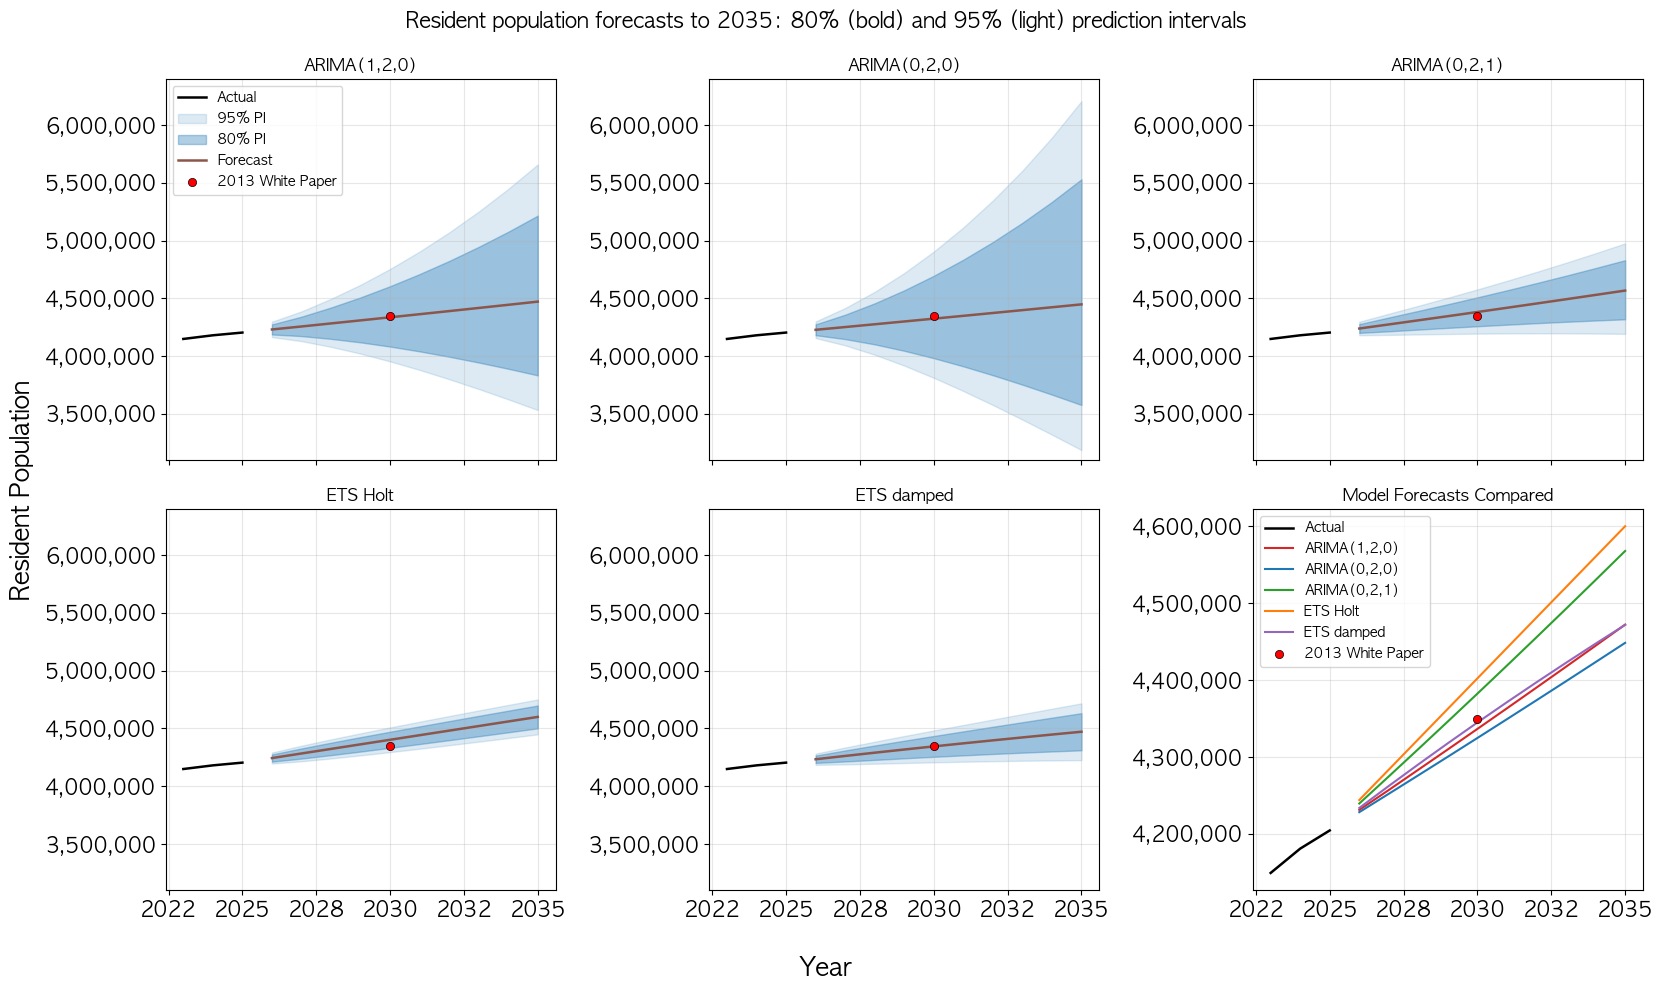

In [19]:
hist = years_r.values >= 2023
fig_fc, axes_fc = plt.subplots(2, 3, figsize=(17, 10), sharex=True)
axes_fc = axes_fc.ravel()

for i, (ax_fc, (name, scale, spec)) in enumerate(zip(axes_fc, best5)):
    fc_mean, lo80, hi80, lo95, hi95 = forecasts[name]
    ax_fc.plot(years_r.values[hist], pop_level[hist], color='black', lw=1.8, label='Actual')
    ax_fc.fill_between(future_years, lo95, hi95, color='tab:blue', alpha=0.15, label='95% PI')
    ax_fc.fill_between(future_years, lo80, hi80, color='tab:blue', alpha=0.35, label='80% PI')
    ax_fc.plot(future_years, fc_mean, color='tab:brown', lw=1.8, label='Forecast')
    ax_fc.scatter([gov_year], [gov_value], color='red', s=35, zorder=8,
               edgecolor='black', linewidth=0.5, label='2013 White Paper')
    ax_fc.set_title(name, fontsize=12)
    ax_fc.grid(True, alpha=0.3)
    ax_fc.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax_fc.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
    ax_fc.set_ylim(3100000, 6400000)

axes_fc[0].legend(loc='upper left', fontsize=10)

# overall panel: point forecasts overlaid, keeping the per-model colour scheme
ax_cmp = axes_fc[5]
ax_cmp.plot(years_r.values[hist], pop_level[hist], color='black', lw=1.8, label='Actual')
for (name, scale, spec), colr in zip(best5, palette):
    ax_cmp.plot(future_years, forecasts[name][0], color=colr, lw=1.5, label=name)
ax_cmp.scatter([gov_year], [gov_value], color='red', s=35, zorder=8,
           edgecolor='black', linewidth=0.5, label='2013 White Paper')
ax_cmp.set_title('Model Forecasts Compared', fontsize=12)
ax_cmp.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax_cmp.grid(True, alpha=0.3)
ax_cmp.legend(loc='upper left', fontsize=10)

fig_fc.suptitle(f'Resident population forecasts to {future_years[-1]}: 80% (bold) and 95% (light) prediction intervals', fontsize=15)
fig_fc.supxlabel('Year'); fig_fc.supylabel('Resident Population')
plt.tight_layout()
plt.show()

The prediction intervals for ARIMA(1,2,0) and ARIMA(0,2,0) are noticeably wider than the other models, as second-order differencing causes forecast variance to widen rapidly over time. While wide intervals ensure safety, predicting a population anywhere between 3,800,000 and 5,500,000 provides little actionable value. ARIMA(0,2,1) seems to have a much narrower prediction interval compared. 

In contrast, ARIMA(0,2,1) produces a significantly narrower prediction interval. This aligns with its superior performance—achieving the lowest AICc (~ -273) among all d=2 candidates in training set and shows that it still performs well on the whole sample in lowering residual variance. 

Singapore Government made a prediction in the 2013 Population White Paper that the resident population will grow to around 4,300,000 to 4,400,000 by 2030. By observation, this prediction lands comfortably within all model 80% intervals, which supports the overall validity of our bounds. However, because it was published in 2013, its benchmarks may no longer reflect recent demographic trends and policy shifts.

### We now bring these models to the next chapter for COE forecasting